In [1]:
import numpy as np
import pandas as pd
import scipy

import random

from simulation.domain.model import construct_well, h_lim, betta_G_lim
from simulation.service_layer.services import get_dict_for_data, build_plot, PlotData, Scale
from simulation.domain.meter import Meter, add_noise
from identification.domain.model import ident_values, identificate, get_data_by_slices, identificate_regul, get_res_dict_for_ident
from src.identification.service_layer.services import calc_rsd_by_series, calc_bias_by_series, calc_error

In [131]:
# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 45000  # Количество точек моделирования
dt = 0.0001  # Суток

w_program = {2: 1.065556, 3: 0.9335, 3.7: 1}

well = construct_well(agzu_on=False, p_L_change_on=False)
well.set_w_program(w_program)


df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df = pd.DataFrame(df)

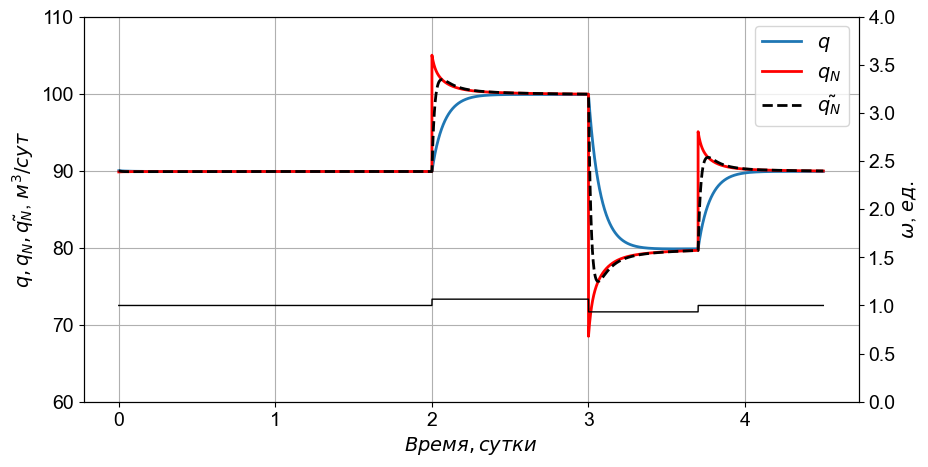

In [112]:
plot_data = [
             {'data': (
                PlotData(df['q'], '', 2, 'q'),
                PlotData(df['q_N'], 'r', 2, 'q_N'),
                PlotData(df['q_L'], 'k--', 2, '\\tilde{q_N}'),
              ), 'x': df['x'], 'y_scale': Scale(min=60, max=110), 'dt': dt, 'mu': 'м^3/сут'},
             {'data': (
               PlotData(df['u'], 'k', 1, '\omega'),
               #PlotData(df['agzu'], 'g', 1, 'АГЗУ'),
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=4), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data)
plot.show()

In [113]:
#df.to_excel("model_output.xlsx")

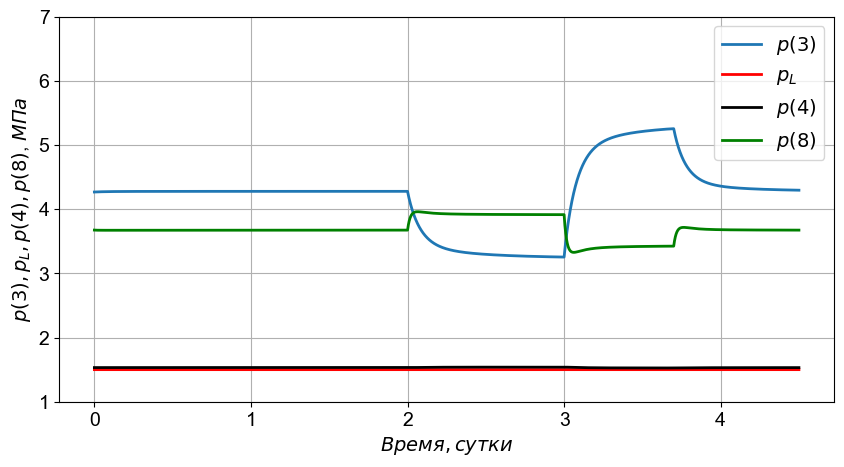

In [114]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], 'k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              ), 'x': df['x'], 'y_scale': Scale(min=1, max=7), 'dt': dt, 'mu': 'МПа'},

]


plot = build_plot(plot_data)
plot.show()

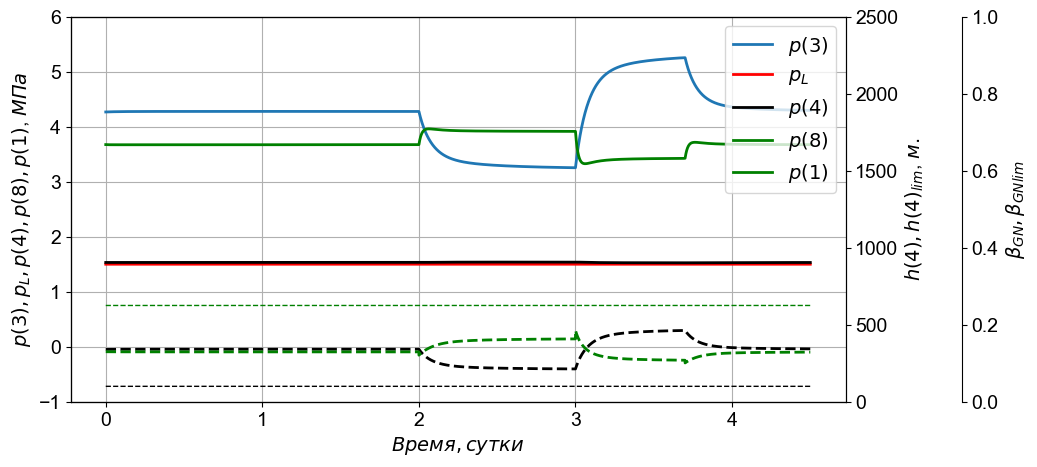

In [115]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], 'k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              PlotData(df['p_1'], 'g', 2, 'p(1)'),
              ), 'x': df['x'], 'y_scale': Scale(min=-1, max=6), 'dt': dt, 'mu': 'МПа'},
            {'data': (
                PlotData(df['h_4'], 'k--', 2, 'h(4)'),
                PlotData(pd.Series([h_lim]*K_NUMBERS), 'k--', 1, 'h(4)_{lim}')
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=2500), 'dt': dt, 'mu': 'м.'},
            {'data': (
                PlotData(df['betta_GN'], 'g--', 2, '\\beta_{GN}'),
                PlotData(pd.Series([betta_G_lim]*K_NUMBERS), 'g--', 1, '\\beta_{GNlim}')
              ), 'x': df['x'], 'y_scale':  Scale(min=0, max=1), 'dt': dt},
]


plot = build_plot(plot_data)
plot.show()

In [8]:
meter = Meter(dt)
meter.noise_enable = True
meter.noise_amplitude = 0.05
ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator = 50)

In [9]:
#df_ident.to_excel("model_measure.xlsx")

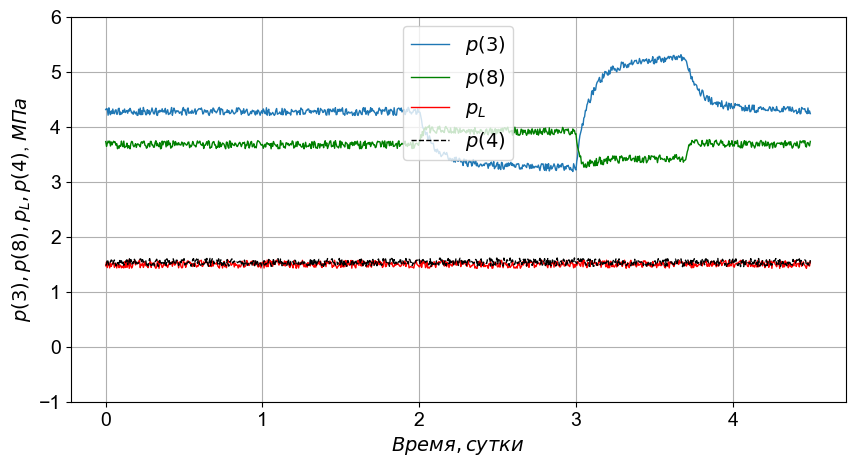

In [10]:
plot_data = [
            {'data': (
              PlotData(df_ident['p_3'], '', 1, 'p(3)'),
              PlotData(df_ident['p_8'], 'g', 1, 'p(8)'),
              PlotData(df_ident['p_L'], 'r', 1, 'p_L'),
              PlotData(df_ident['p_4'], 'k--', 1, 'p(4)'),
              ), 'x': df_ident['x'], 'y_scale': Scale(min=-1, max=6), 'dt': dt, 'mu': 'МПа'},
            ]

plot = build_plot(plot_data)
plot.show()

In [140]:
# Иерархичная идентификация

experiment_num_max = 25

res = {
    'p_R': np.zeros(experiment_num_max),
    'r_1': np.zeros(experiment_num_max),
    'r_2': np.zeros(experiment_num_max),
}

T_experiment = []
t_N_experiment = []
for i in range(experiment_num_max):
    T_experiment.append(random.uniform(well.reservoir.T_2 * 0.8, well.reservoir.T_2 * 1.2))
    t_N_experiment.append(random.uniform(well.pump.t_N * 0.8, well.pump.t_N * 1.2))

T_experiment = np.array(T_experiment)
t_N_experiment = np.array(t_N_experiment)

J = []

meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

for experiment_num in range(experiment_num_max):

  well.reservoir.T_2 = T_experiment[experiment_num]
  well.pump.t_N = t_N_experiment[experiment_num]

  calc_df = ident_values(ident_k, ident_dt, df_ident, well, filter_name=None)

  b, squared_error_sum = identificate(calc_df, ident_k)

  res['p_R'][experiment_num] = b[0]
  res['r_1'][experiment_num] = b[1]
  res['r_2'][experiment_num] = b[2]

  J.append(squared_error_sum)

X = np.array([[1]*experiment_num_max,
              T_experiment,
              t_N_experiment,
              T_experiment**2,
              2*T_experiment*t_N_experiment,
              t_N_experiment**2
             ]).T

y = np.array(J).T
a, squared_error_sum, matrix_rank, SVD_ = scipy.linalg.lstsq(X, y)


X1 = np.array([
    [2*a[3], 2*a[4]],
    [2*a[4], 2*a[5]]
])

Y1 = np.array([
    [-a[1]],
    [-a[2]]
])

times = np.linalg.inv(X1).dot(Y1)

In [144]:
times

array([[0.39872809],
       [0.02012053]])